In [ ]:
# Install required packages
# Gerekli paketlerin kurulumu
!pip install -q albumentations timm openpyxl

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Paths
# Yollar
DATA_ROOT = "/content/drive/MyDrive/mini_dataset_2000"   # ham orijinal, a/b/c/d
OUTPUT_ROOT = "/content/drive/MyDrive/breast_density/EfficientNetUNet_paper_faithful"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

CLASSES = ["a", "b", "c", "d"]

# Paper hyperparameters (Triqui & Kaid-Slimane, Diagnostics 2026)
# Makale hiperparametreleri
IMG_SIZE = 380                    # EfficientNet-B4 dogal boyutu
BATCH_SIZE = 16                   # makale
MAX_EPOCHS = 50                   # makale
PATIENCE = 10                     # makale early stopping
LR_ENCODER = 1e-5                 # makale encoder LR
LR_DECODER = 1e-4                 # makale decoder LR
LABEL_SMOOTHING = 0.1             # makale
DROPOUT = 0.3                     # makale classification head
T_0 = 5                           # CosineAnnealingWarmRestarts
SEED = 42

# Split ratios (paper uses patient-wise split)
# Split oranlari (makale hasta bazli split kullaniyor)
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.80, 0.10, 0.10

assert os.path.exists(DATA_ROOT), f"DATA_ROOT bulunamadi: {DATA_ROOT}"
print("Veri dizini:", DATA_ROOT)
print(f"Makale ayarlari: {IMG_SIZE}x{IMG_SIZE}, batch {BATCH_SIZE}, "
      f"AdamW (enc {LR_ENCODER}, dec {LR_DECODER}), label smoothing {LABEL_SMOOTHING}")

Veri dizini: /content/drive/MyDrive/mini_dataset_2000
Makale ayarlari: 380x380, batch 16, AdamW (enc 1e-05, dec 0.0001), label smoothing 0.1


In [ ]:
import pandas as pd

def parse_filename(fname):
    # Parse {ID}_{SIDE}{VIEW}.png
    # {ID}_{TARAF}{GORUNUM}.png ayristir
    base = os.path.splitext(fname)[0]
    parts = base.split("_")
    if len(parts) != 2:
        return None
    pid = parts[0]
    code = parts[1].upper()
    side, view = code[0], code[1:]
    if side not in ["L", "R"] or view not in ["CC", "MLO"]:
        return None
    return pid, side, view

rows = []
for label in CLASSES:
    class_dir = os.path.join(DATA_ROOT, label)
    if not os.path.isdir(class_dir):
        continue
    for fname in os.listdir(class_dir):
        if not fname.lower().endswith(".png"):
            continue
        parsed = parse_filename(fname)
        if parsed is None:
            continue
        pid, side, view = parsed
        rows.append({"patient_id": pid, "side": side, "view": view,
                     "label": label, "filepath": os.path.join(class_dir, fname)})

df = pd.DataFrame(rows)

# Breast-level table (one row per breast, CC and MLO paths)
# Meme bazli tablo (her satir bir meme, CC ve MLO yollari)
breast_df = df.pivot_table(index=["patient_id", "side", "label"],
                           columns="view", values="filepath", aggfunc="first").reset_index()
breast_df.columns.name = None
breast_df = breast_df.rename(columns={"CC": "cc_path", "MLO": "mlo_path"})

label_to_idx = {c: i for i, c in enumerate(CLASSES)}
breast_df["label_idx"] = breast_df["label"].map(label_to_idx)

print("Toplam goruntu:", len(df))
print("Toplam meme:", len(breast_df))
print("\nSinif dagilimi:")
print(breast_df["label"].value_counts())

Toplam goruntu: 8000
Toplam meme: 4000

Sinif dagilimi:
label
b    1414
c    1398
d     694
a     494
Name: count, dtype: int64


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold

# Patient-wise stratified split, 80/10/10 (paper protocol)
# Hasta bazli stratified split, 80/10/10 (makale protokolu)
np.random.seed(SEED)

X = np.arange(len(breast_df))
y = breast_df["label_idx"].values
groups = breast_df["patient_id"].values

# First: separate test (10%)
# Once: test ayir (%10)
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEED)
trainval_idx, test_idx = next(iter(sgkf.split(X, y, groups)))

# Then: separate val (10% of total) from trainval
# Sonra: trainval icinden val ayir (toplam %10)
X_tv = trainval_idx
y_tv = y[trainval_idx]
g_tv = groups[trainval_idx]

sgkf2 = StratifiedGroupKFold(n_splits=9, shuffle=True, random_state=SEED)
tr_rel, val_rel = next(iter(sgkf2.split(X_tv, y_tv, g_tv)))

train_idx = trainval_idx[tr_rel]
val_idx = trainval_idx[val_rel]

breast_df["split"] = "train"
breast_df.loc[val_idx, "split"] = "val"
breast_df.loc[test_idx, "split"] = "test"

print("Split boyutlari:")
print(breast_df["split"].value_counts())
print("\nOranlar (%):")
print((breast_df["split"].value_counts() / len(breast_df) * 100).round(1))

# Verify no patient leakage
# Hasta sizintisi kontrolu
tr_p = set(breast_df[breast_df["split"] == "train"]["patient_id"])
va_p = set(breast_df[breast_df["split"] == "val"]["patient_id"])
te_p = set(breast_df[breast_df["split"] == "test"]["patient_id"])

print("\nSizinti kontrolu:")
print("Train-Val:", len(tr_p & va_p))
print("Train-Test:", len(tr_p & te_p))
print("Val-Test:", len(va_p & te_p))
assert not (tr_p & va_p) and not (tr_p & te_p) and not (va_p & te_p), "Sizinti var!"
print("Sizinti yok.")

# Class distribution per split
# Split basina sinif dagilimi
print("\nSplit basina sinif dagilimi (%):")
print((breast_df.groupby("split")["label"].value_counts(normalize=True).unstack() * 100).round(1))

# Reduce batch for T4 memory, keep effective batch 16 via accumulation
# T4 bellegi icin batch kucult, accumulation ile efektif batch 16 korunur
BATCH_SIZE = 8
ACCUM_STEPS = 2

# Save table
# Tabloyu kaydet
table_path = os.path.join(OUTPUT_ROOT, "breast_table.csv")
breast_df.to_csv(table_path, index=False)
print(f"\nTablo kaydedildi: {table_path}")

Split boyutlari:
split
train    3200
test      400
val       400
Name: count, dtype: int64

Oranlar (%):
split
train    80.0
test     10.0
val      10.0
Name: count, dtype: float64

Sizinti kontrolu:
Train-Val: 0
Train-Test: 0
Val-Test: 0
Sizinti yok.

Split basina sinif dagilimi (%):
label     a     b     c     d
split                        
test   11.5  37.0  33.5  18.0
train  12.1  35.1  35.2  17.6
val    15.0  35.5  34.5  15.0

Tablo kaydedildi: /content/drive/MyDrive/breast_density/EfficientNetUNet_paper_faithful/breast_table.csv


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Paper augmentation, corrected for current albumentations API
# Makale augmentation, guncel albumentations API'sine gore duzeltildi
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Affine(translate_percent=0.0625, scale=(0.9, 1.1), rotate=(-15, 15),
             border_mode=cv2.BORDER_CONSTANT, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.CoarseDropout(num_holes_range=(4, 8),
                    hole_height_range=(int(IMG_SIZE * 0.05), int(IMG_SIZE * 0.1)),
                    hole_width_range=(int(IMG_SIZE * 0.05), int(IMG_SIZE * 0.1)),
                    fill=0, p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

class BreastDensityDataset(Dataset):
    # Two-view dataset, grayscale duplicated to 3 channels (paper method)
    # Iki gorunumlu veri seti, gri tonlama 3 kanala kopyalanir (makale yontemi)

    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _load(self, path):
        # Read grayscale, duplicate to 3 channels for pretrained CNN
        # Gri tonlamali oku, on egitimli CNN icin 3 kanala kopyala
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Okunamadi: {path}")
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        cc = self._load(row["cc_path"])
        mlo = self._load(row["mlo_path"])
        cc = self.transform(image=cc)["image"]
        mlo = self.transform(image=mlo)["image"]
        return cc, mlo, int(row["label_idx"])

# Build loaders
# Yukleyicileri olustur
train_df = breast_df[breast_df["split"] == "train"].copy()
val_df = breast_df[breast_df["split"] == "val"].copy()
test_df = breast_df[breast_df["split"] == "test"].copy()

train_loader = DataLoader(BreastDensityDataset(train_df, train_transform),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
                          pin_memory=True, drop_last=True)
val_loader = DataLoader(BreastDensityDataset(val_df, eval_transform),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(BreastDensityDataset(test_df, eval_transform),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("DataLoader'lar hazir.")
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Sanity check
# Hizli kontrol
cc, mlo, lbl = next(iter(train_loader))
print(f"\nCC: {cc.shape}, MLO: {mlo.shape}, etiket: {lbl[:8].tolist()}")

DataLoader'lar hazir.
Train: 3200, Val: 400, Test: 400

CC: torch.Size([8, 3, 380, 380]), MLO: torch.Size([8, 3, 380, 380]), etiket: [1, 2, 1, 1, 1, 0, 2, 1]


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as tv_models

class EfficientNetB4Encoder(nn.Module):
    # EfficientNet-B4 encoder from torchvision (avoids HF download rate limits)
    # torchvision'dan EfficientNet-B4 encoder (HF indirme limitlerini onler)
    # Blocks are grouped into 5 stages to produce multi-scale features P0-P4
    # Bloklar 5 asamaya gruplanir, P0-P4 cok olcekli oznitelikler uretir

    def __init__(self, pretrained=True):
        super().__init__()
        weights = tv_models.EfficientNet_B4_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = tv_models.efficientnet_b4(weights=weights)
        feats = backbone.features

        self.stage0 = nn.Sequential(feats[0], feats[1])   # stride 2
        self.stage1 = feats[2]                            # stride 4
        self.stage2 = feats[3]                            # stride 8
        self.stage3 = nn.Sequential(feats[4], feats[5])   # stride 16
        self.stage4 = nn.Sequential(feats[6], feats[7])   # stride 32

        # Channel counts for EfficientNet-B4 stages
        # EfficientNet-B4 asama kanal sayilari
        self.out_channels = [24, 32, 56, 160, 448]

    def forward(self, x):
        f0 = self.stage0(x)
        f1 = self.stage1(f0)
        f2 = self.stage2(f1)
        f3 = self.stage3(f2)
        f4 = self.stage4(f3)
        return [f0, f1, f2, f3, f4]

class ConvBlock(nn.Module):
    # Two successive conv + BatchNorm + ReLU (paper Section 3.3.1)
    # Iki ardisik conv + BatchNorm + ReLU (makale)

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class EfficientNetUNetBranch(nn.Module):
    # Single-view branch: EfficientNet-B4 encoder + U-Net decoder
    # Tek gorunum dali: EfficientNet-B4 encoder + U-Net decoder
    # Decoder is used for spatial feature refinement, not segmentation (paper Section 5.2)
    # Decoder segmentasyon icin degil, uzamsal oznitelik zenginlestirme icin (makale)

    def __init__(self, pretrained=True):
        super().__init__()
        self.encoder = EfficientNetB4Encoder(pretrained=pretrained)
        ch = self.encoder.out_channels   # [24, 32, 56, 160, 448]

        # Decoder: 4 stages, each ConvTranspose2d + ConvBlock with skip connection
        # Decoder: 4 asama, her biri ConvTranspose2d + ConvBlock, skip connection ile
        self.up4 = nn.ConvTranspose2d(ch[4], ch[3], kernel_size=2, stride=2)
        self.dec4 = ConvBlock(ch[3] * 2, ch[3])

        self.up3 = nn.ConvTranspose2d(ch[3], ch[2], kernel_size=2, stride=2)
        self.dec3 = ConvBlock(ch[2] * 2, ch[2])

        self.up2 = nn.ConvTranspose2d(ch[2], ch[1], kernel_size=2, stride=2)
        self.dec2 = ConvBlock(ch[1] * 2, ch[1])

        self.up1 = nn.ConvTranspose2d(ch[1], ch[0], kernel_size=2, stride=2)
        self.dec1 = ConvBlock(ch[0] * 2, ch[0])

        self.out_channels = ch[0]
        self.gap = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        feats = self.encoder(x)

        d4 = self.up4(feats[4])
        d4 = self._match_and_cat(d4, feats[3])
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = self._match_and_cat(d3, feats[2])
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = self._match_and_cat(d2, feats[1])
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = self._match_and_cat(d1, feats[0])
        d1 = self.dec1(d1)

        return torch.flatten(self.gap(d1), 1)

    @staticmethod
    def _match_and_cat(up, skip):
        # Align spatial sizes before concatenation
        # Birlestirmeden once uzamsal boyutlari hizala
        if up.shape[-2:] != skip.shape[-2:]:
            up = nn.functional.interpolate(up, size=skip.shape[-2:],
                                           mode="bilinear", align_corners=False)
        return torch.cat([up, skip], dim=1)

class EfficientNetUNet(nn.Module):
    # Two-view model: separate branches for CC and MLO, feature-level concatenation
    # Iki gorunumlu model: CC ve MLO icin ayri dallar, oznitelik seviyesinde birlestirme

    def __init__(self, num_classes=4, pretrained=True, dropout=DROPOUT):
        super().__init__()
        self.cc_branch = EfficientNetUNetBranch(pretrained=pretrained)
        self.mlo_branch = EfficientNetUNetBranch(pretrained=pretrained)

        feat_dim = self.cc_branch.out_channels

        # Classification head: dropout + linear (paper)
        # Siniflandirma basligi: dropout + linear (makale)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim * 2, num_classes)
        )

    def forward(self, cc, mlo):
        cc_feat = self.cc_branch(cc)
        mlo_feat = self.mlo_branch(mlo)
        # Feature-level concatenation (paper Eq. 1)
        # Oznitelik seviyesinde birlestirme (makale Denklem 1)
        fused = torch.cat([cc_feat, mlo_feat], dim=1)
        return self.classifier(fused)

# Quick test
# Hizli test
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Cihaz:", device)

_m = EfficientNetUNet(num_classes=4, pretrained=True).to(device)
_cc = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
_mlo = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
with torch.no_grad():
    _out = _m(_cc, _mlo)
print("Cikti sekli:", _out.shape)   # beklenen [2, 4]
print(f"Toplam parametre: {sum(p.numel() for p in _m.parameters())/1e6:.1f}M")

del _m, _cc, _mlo
torch.cuda.empty_cache()

Cihaz: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 147MB/s]


Cikti sekli: torch.Size([2, 4])
Toplam parametre: 35.8M


In [ ]:
import torch.optim as optim
import os
import shutil

# Local fast dir for checkpoints (avoid Drive freeze, lesson from first model)
# Checkpoint icin hizli lokal dizin (Drive donmasini onle, ilk modelden ders)
LOCAL_OUT = "/content/local_out_effunet"
os.makedirs(LOCAL_OUT, exist_ok=True)
SYNC_EVERY = 10

LAST_CKPT = os.path.join(LOCAL_OUT, "last.pt")
BEST_CKPT = os.path.join(LOCAL_OUT, "best.pt")
EXCEL_LOG = os.path.join(LOCAL_OUT, "log.xlsx")

DRIVE_CKPT_DIR = os.path.join(OUTPUT_ROOT, "checkpoints")

# Model
model = EfficientNetUNet(num_classes=4, pretrained=True, dropout=DROPOUT).to(device)

# Loss: CrossEntropy with label smoothing 0.1 (paper)
# Kayip: label smoothing 0.1 ile CrossEntropy (makale)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# Optimizer: AdamW with separate LR for encoder and decoder (paper)
# Optimizer: encoder ve decoder icin ayri LR ile AdamW (makale)
encoder_params = list(model.cc_branch.encoder.parameters()) + \
                 list(model.mlo_branch.encoder.parameters())

# Everything else (decoders + classifier) uses decoder LR
# Geri kalan her sey (decoder'lar + classifier) decoder LR kullanir
encoder_ids = {id(p) for p in encoder_params}
decoder_params = [p for p in model.parameters() if id(p) not in encoder_ids]

optimizer = optim.AdamW([
    {"params": encoder_params, "lr": LR_ENCODER},
    {"params": decoder_params, "lr": LR_DECODER},
])

# Scheduler: CosineAnnealingWarmRestarts, T_0 = 5 (paper)
# Scheduler: CosineAnnealingWarmRestarts, T_0 = 5 (makale)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=T_0)

def save_ckpt(path, epoch, model, optimizer, scheduler, best_val_loss, no_improve):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_loss": best_val_loss,
        "no_improve": no_improve,
    }, path)

def sync_to_drive(local_dir, drive_dir):
    # Copy only the needed files, overwrite in place, no deletion
    # Sadece gerekli dosyalari kopyala, uzerine yaz, silme yok
    # Avoids rmtree + copytree which caused Drive freezes
    # Drive donmasina yol acan rmtree + copytree kullanilmaz
    os.makedirs(drive_dir, exist_ok=True)
    for fname in ["last.pt", "best.pt", "log.xlsx"]:
        src = os.path.join(local_dir, fname)
        if not os.path.exists(src):
            continue
        try:
            shutil.copy2(src, os.path.join(drive_dir, fname))
        except Exception as e:
            # Drive can be flaky; log and continue, local copy is safe
            # Drive kararsiz olabilir; logla ve devam et, lokal kopya guvende
            print(f"  Uyari: {fname} Drive'a yazilamadi ({e})")

# Resume: check local first, then Drive
# Devam: once lokal, sonra Drive kontrol et
start_epoch, best_val_loss, no_improve = 0, float("inf"), 0

if not os.path.exists(LAST_CKPT) and os.path.exists(os.path.join(DRIVE_CKPT_DIR, "last.pt")):
    sync_to_drive(DRIVE_CKPT_DIR, LOCAL_OUT)
    print("Drive'dan checkpoint lokale cekildi.")

if os.path.exists(LAST_CKPT):
    ck = torch.load(LAST_CKPT, map_location=device)
    model.load_state_dict(ck["model_state"])
    optimizer.load_state_dict(ck["optimizer_state"])
    scheduler.load_state_dict(ck["scheduler_state"])
    start_epoch = ck["epoch"] + 1
    best_val_loss = ck["best_val_loss"]
    no_improve = ck["no_improve"]
    print(f"Checkpoint bulundu. Epoch {start_epoch}'dan devam ediliyor.")
else:
    print("Sifirdan baslaniyor.")

print(f"\nMakale kurulumu: AdamW (enc {LR_ENCODER}, dec {LR_DECODER}), "
      f"CosineAnnealingWarmRestarts T_0={T_0}, label smoothing {LABEL_SMOOTHING}")

Drive'dan checkpoint lokale cekildi.
Checkpoint bulundu. Epoch 39'dan devam ediliyor.

Makale kurulumu: AdamW (enc 1e-05, dec 0.0001), CosineAnnealingWarmRestarts T_0=5, label smoothing 0.1


In [ ]:
import numpy as np
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes=4):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    for cc, mlo, labels in loader:
        cc, mlo, labels = cc.to(device), mlo.to(device), labels.to(device)
        outputs = model(cc, mlo)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * labels.size(0)

        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)

    metrics = {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
    }
    try:
        metrics["macro_auc"] = roc_auc_score(all_labels, all_probs,
                                             multi_class="ovr", average="macro")
    except ValueError:
        metrics["macro_auc"] = float("nan")

    per_class = f1_score(all_labels, all_preds, average=None, labels=list(range(num_classes)))
    for i in range(num_classes):
        metrics[f"f1_{CLASSES[i]}"] = per_class[i]

    return metrics, all_labels, all_preds, all_probs

print("Metrik fonksiyonu hazir.")

Metrik fonksiyonu hazir.


In [ ]:
from tqdm import tqdm
import pandas as pd

# Load existing log, remove any epochs >= start_epoch to avoid duplicates on resume
# Mevcut logu yukle, resume'da tekrari onlemek icin start_epoch ve sonrasini temizle
if os.path.exists(EXCEL_LOG):
    _log_df = pd.read_excel(EXCEL_LOG)
    # Keep only epochs before where we resume, drop the rest
    # Sadece devam ettigimiz noktadan onceki epochlari tut, gerisini at
    _log_df = _log_df[_log_df["epoch"] < start_epoch]
    log_rows = _log_df.to_dict("records")
else:
    log_rows = []

def train_one_epoch(model, loader, criterion, optimizer, device, accum_steps=1):
    # Training with gradient accumulation
    # Gradient accumulation ile egitim
    # Gradients are accumulated over accum_steps mini-batches, then one update
    # Gradyanlar accum_steps mini-batch boyunca biriktirilir, sonra tek guncelleme
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()

    for i, (cc, mlo, labels) in enumerate(tqdm(loader, desc="Train", leave=False)):
        cc, mlo, labels = cc.to(device), mlo.to(device), labels.to(device)

        outputs = model(cc, mlo)
        loss = criterion(outputs, labels)

        # Scale loss by accumulation steps so gradients average correctly
        # Gradyanlar dogru ortalansin diye kaybi accumulation adimina bol
        (loss / accum_steps).backward()

        # Update weights every accum_steps
        # Her accum_steps'te agirliklari guncelle
        if (i + 1) % accum_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

        total_loss += loss.item() * labels.size(0)

    # Handle any leftover gradients at the end of the epoch
    # Epoch sonunda kalan gradyanlari isle
    if len(loader) % accum_steps != 0:
        optimizer.step()
        optimizer.zero_grad()

    return total_loss / len(loader.dataset)

print(f"Egitim basliyor. Epoch {start_epoch} -> {MAX_EPOCHS - 1}")
print(f"Efektif batch: {BATCH_SIZE} x {ACCUM_STEPS} = {BATCH_SIZE * ACCUM_STEPS}\n")

for epoch in range(start_epoch, MAX_EPOCHS):
    train_one_epoch(model, train_loader, criterion, optimizer, device, accum_steps=ACCUM_STEPS)

    tr_m, _, _, _ = evaluate(model, train_loader, criterion, device)
    va_m, _, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step()
    lr_enc = optimizer.param_groups[0]["lr"]
    lr_dec = optimizer.param_groups[1]["lr"]

    print(f"E{epoch:02d} | tr_loss {tr_m['loss']:.3f} acc {tr_m['accuracy']:.3f} | "
          f"va_loss {va_m['loss']:.3f} acc {va_m['accuracy']:.3f} f1 {va_m['macro_f1']:.3f} | "
          f"lr {lr_enc:.1e}/{lr_dec:.1e}")

    row = {"epoch": epoch, "lr_encoder": lr_enc, "lr_decoder": lr_dec}
    for k, v in tr_m.items(): row[f"train_{k}"] = v
    for k, v in va_m.items(): row[f"val_{k}"] = v
    log_rows.append(row)
    pd.DataFrame(log_rows).to_excel(EXCEL_LOG, index=False)

    if va_m["loss"] < best_val_loss:
        best_val_loss = va_m["loss"]
        no_improve = 0
        save_ckpt(BEST_CKPT, epoch, model, optimizer, scheduler, best_val_loss, no_improve)
        print(f"  -> Yeni en iyi val loss: {best_val_loss:.4f}")
    else:
        no_improve += 1
        print(f"  -> Iyilesme yok ({no_improve}/{PATIENCE})")

    save_ckpt(LAST_CKPT, epoch, model, optimizer, scheduler, best_val_loss, no_improve)

    if (epoch + 1) % SYNC_EVERY == 0:
        sync_to_drive(LOCAL_OUT, DRIVE_CKPT_DIR)
        print(f"  (Drive'a senkronize edildi)")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping: {PATIENCE} epoch iyilesme yok.")
        break

sync_to_drive(LOCAL_OUT, DRIVE_CKPT_DIR)
print("\nEgitim tamamlandi.")
print(f"En iyi val loss: {best_val_loss:.4f}")

Egitim basliyor. Epoch 10 -> 49
Efektif batch: 8 x 2 = 16



E10 | tr_loss 0.853 acc 0.732 | va_loss 0.863 acc 0.730 f1 0.714 | lr 9.0e-06/9.0e-05
  -> Iyilesme yok (2/10)


E11 | tr_loss 0.841 acc 0.730 | va_loss 0.853 acc 0.745 f1 0.731 | lr 6.5e-06/6.5e-05
  -> Yeni en iyi val loss: 0.8530


E12 | tr_loss 0.812 acc 0.748 | va_loss 0.842 acc 0.728 f1 0.691 | lr 3.5e-06/3.5e-05
  -> Yeni en iyi val loss: 0.8422


E13 | tr_loss 0.806 acc 0.744 | va_loss 0.837 acc 0.718 f1 0.661 | lr 9.5e-07/9.5e-06
  -> Yeni en iyi val loss: 0.8371


...

E34 | tr_loss 0.747 acc 0.788 | va_loss 0.829 acc 0.735 f1 0.714 | lr 1.0e-05/1.0e-04
  -> Iyilesme yok (6/10)


E35 | tr_loss 0.747 acc 0.791 | va_loss 0.828 acc 0.738 f1 0.707 | lr 9.0e-06/9.0e-05
  -> Iyilesme yok (7/10)


E36 | tr_loss 0.721 acc 0.801 | va_loss 0.819 acc 0.733 f1 0.713 | lr 6.5e-06/6.5e-05
  -> Iyilesme yok (8/10)


E37 | tr_loss 0.736 acc 0.796 | va_loss 0.838 acc 0.718 f1 0.694 | lr 3.5e-06/3.5e-05
  -> Iyilesme yok (9/10)


E38 | tr_loss 0.704 acc 0.822 | va_loss 0.824 acc 0.718 f1 0.685 | lr 9.5e-07/9.5e-06
  -> Iyilesme yok (10/10)

Early stopping: 10 epoch iyilesme yok.

Egitim tamamlandi.
En iyi val loss: 0.8072


In [ ]:
import torch
import numpy as np
import torch.nn.functional as F
from torch.amp import autocast
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, cohen_kappa_score, roc_auc_score)
import pandas as pd

# Load best model
# En iyi modeli yukle
ck = torch.load(BEST_CKPT, map_location=device)
model.load_state_dict(ck["model_state"])
model.eval()
print(f"En iyi model yuklendi (epoch {ck['epoch']}, val_loss {ck['best_val_loss']:.4f})")

@torch.no_grad()
def evaluate_full(model, loader, device):
    # Full evaluation returning labels, preds, probs
    # Etiket, tahmin, olasilik donduren tam degerlendirme
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for cc, mlo, labels in loader:
        cc, mlo = cc.to(device), mlo.to(device)
        with autocast("cuda"):
            outputs = model(cc, mlo)
        probs = F.softmax(outputs.float(), dim=1)
        all_preds.append(outputs.argmax(dim=1).cpu().numpy())
        all_labels.append(labels.numpy())
        all_probs.append(probs.cpu().numpy())
    return (np.concatenate(all_labels), np.concatenate(all_preds),
            np.concatenate(all_probs))

y_test, preds_test, probs_test = evaluate_full(model, test_loader, device)


print("EFFICIENTNET-UNET TEST SONUCLARI")
print(f"Accuracy:        {accuracy_score(y_test, preds_test):.4f}")
print(f"Macro F1:        {f1_score(y_test, preds_test, average='macro'):.4f}")
print(f"Macro AUC:       {roc_auc_score(y_test, probs_test, multi_class='ovr', average='macro'):.4f}")
print(f"Cohen Kappa:     {cohen_kappa_score(y_test, preds_test):.4f}")
print(f"Weighted Kappa:  {cohen_kappa_score(y_test, preds_test, weights='quadratic'):.4f}")

print("\nSiniflandirma Raporu")
print(classification_report(y_test, preds_test, target_names=CLASSES, digits=3))

print("Confusion Matrix")
cm = confusion_matrix(y_test, preds_test)
print(pd.DataFrame(cm, index=[f"gercek_{c}" for c in CLASSES],
                   columns=[f"tahmin_{c}" for c in CLASSES]))

En iyi model yuklendi (epoch 28, val_loss 0.8072)
EFFICIENTNET-UNET TEST SONUCLARI
Accuracy:        0.7400
Macro F1:        0.7291
Macro AUC:       0.9279
Cohen Kappa:     0.6351
Weighted Kappa:  0.8406

Siniflandirma Raporu
              precision    recall  f1-score   support

           a      0.579     0.717     0.641        46
           b      0.776     0.703     0.738       148
           c      0.752     0.769     0.760       134
           d      0.778     0.778     0.778        72

    accuracy                          0.740       400
   macro avg      0.721     0.742     0.729       400
weighted avg      0.746     0.740     0.741       400

Confusion Matrix
          tahmin_a  tahmin_b  tahmin_c  tahmin_d
gercek_a        33        13         0         0
gercek_b        24       104        18         2
gercek_c         0        17       103        14
gercek_d         0         0        16        56


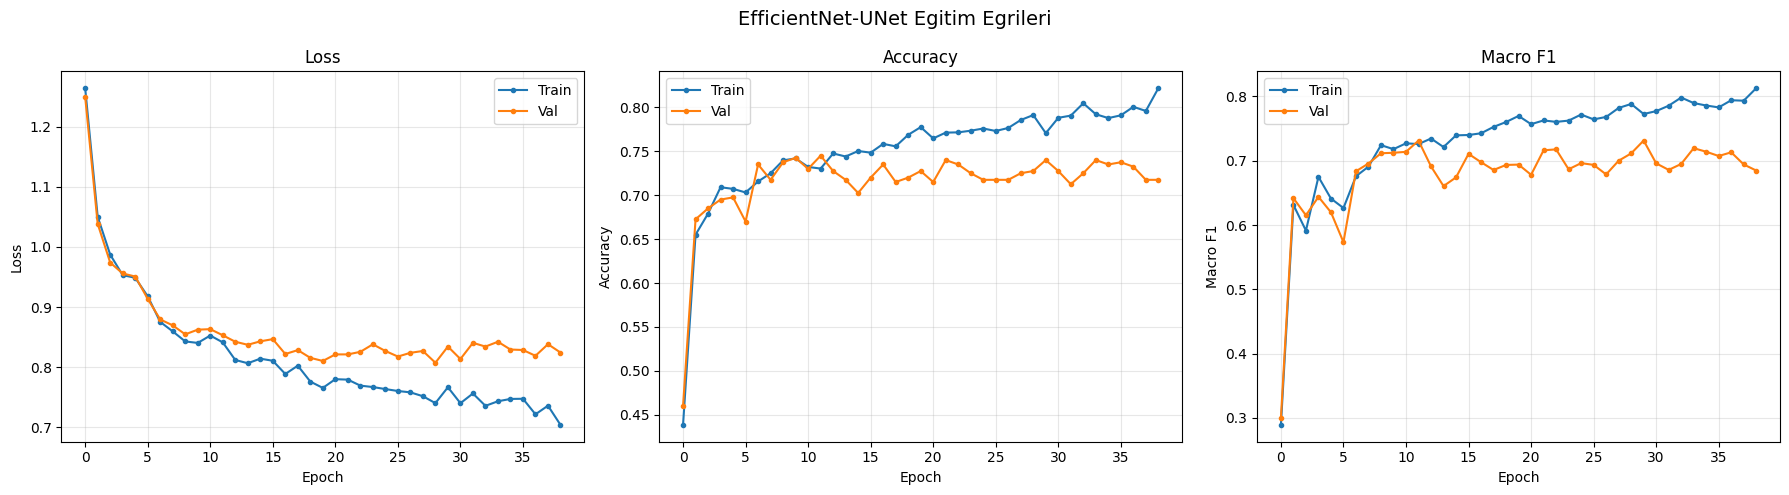

Kaydedildi: /content/drive/MyDrive/breast_density/EfficientNetUNet_paper_faithful/training_curves.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Read training log (try Drive first, then local)
# Egitim logunu oku (once Drive, sonra lokal)
log_path = os.path.join(DRIVE_CKPT_DIR, "log.xlsx")
if not os.path.exists(log_path):
    log_path = EXCEL_LOG
log_df = pd.read_excel(log_path)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric, title) in zip(axes, [("loss", "Loss"),
                                       ("accuracy", "Accuracy"),
                                       ("macro_f1", "Macro F1")]):
    ax.plot(log_df["epoch"], log_df[f"train_{metric}"], marker="o", markersize=3, label="Train")
    ax.plot(log_df["epoch"], log_df[f"val_{metric}"], marker="o", markersize=3, label="Val")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("EfficientNet-UNet Egitim Egrileri", fontsize=14)
plt.tight_layout()

save_path = os.path.join(OUTPUT_ROOT, "training_curves.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaydedildi: {save_path}")

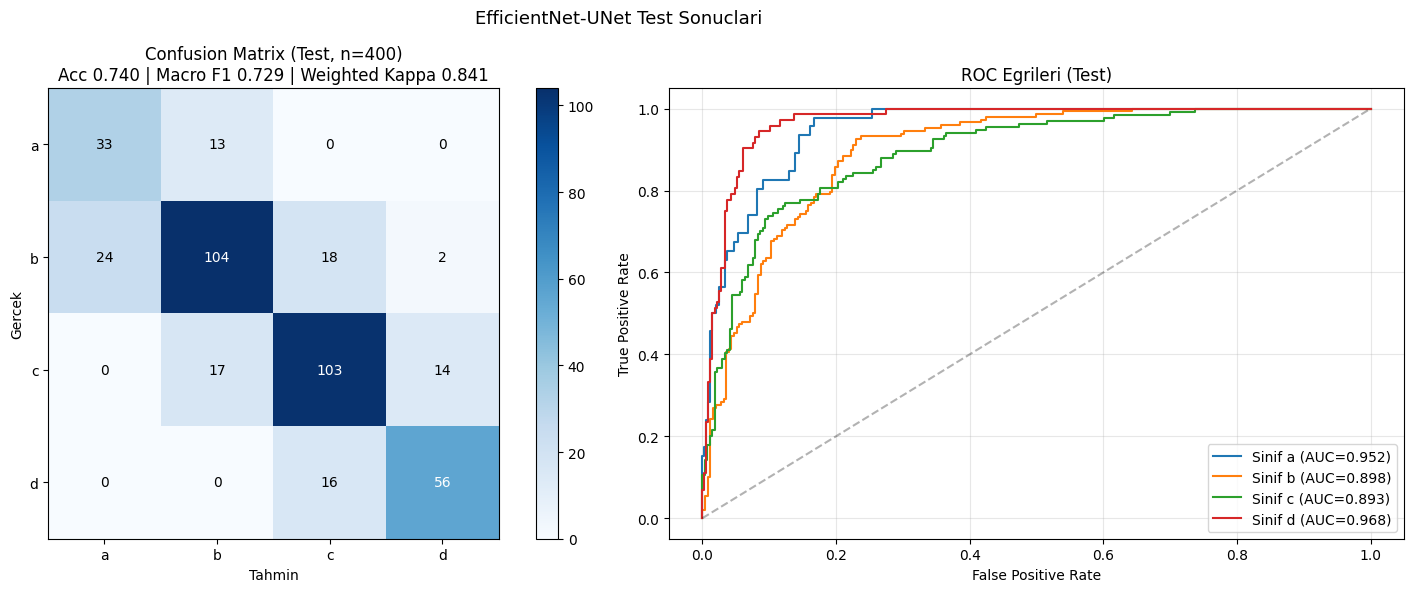

Kaydedildi: /content/drive/MyDrive/breast_density/EfficientNetUNet_paper_faithful/test_confusion_roc.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                             accuracy_score, f1_score, cohen_kappa_score)
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
# Karisiklik matrisi
cm = confusion_matrix(y_test, preds_test)
im = axes[0].imshow(cm, cmap="Blues")

acc = accuracy_score(y_test, preds_test)
mf1 = f1_score(y_test, preds_test, average="macro")
wk = cohen_kappa_score(y_test, preds_test, weights="quadratic")

axes[0].set_title(f"Confusion Matrix (Test, n={len(y_test)})\n"
                  f"Acc {acc:.3f} | Macro F1 {mf1:.3f} | Weighted Kappa {wk:.3f}")
axes[0].set_xlabel("Tahmin")
axes[0].set_ylabel("Gercek")
axes[0].set_xticks(range(len(CLASSES)))
axes[0].set_yticks(range(len(CLASSES)))
axes[0].set_xticklabels(CLASSES)
axes[0].set_yticklabels(CLASSES)

for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        axes[0].text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=axes[0], fraction=0.046)

# ROC curves
# ROC egrileri
y_test_bin = label_binarize(y_test, classes=list(range(len(CLASSES))))
for i, c in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs_test[:, i])
    axes[1].plot(fpr, tpr, label=f"Sinif {c} (AUC={auc(fpr, tpr):.3f})")

axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_title("ROC Egrileri (Test)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("EfficientNet-UNet Test Sonuclari", fontsize=13)
plt.tight_layout()

save_path = os.path.join(OUTPUT_ROOT, "test_confusion_roc.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaydedildi: {save_path}")

Grad-CAM hazir.


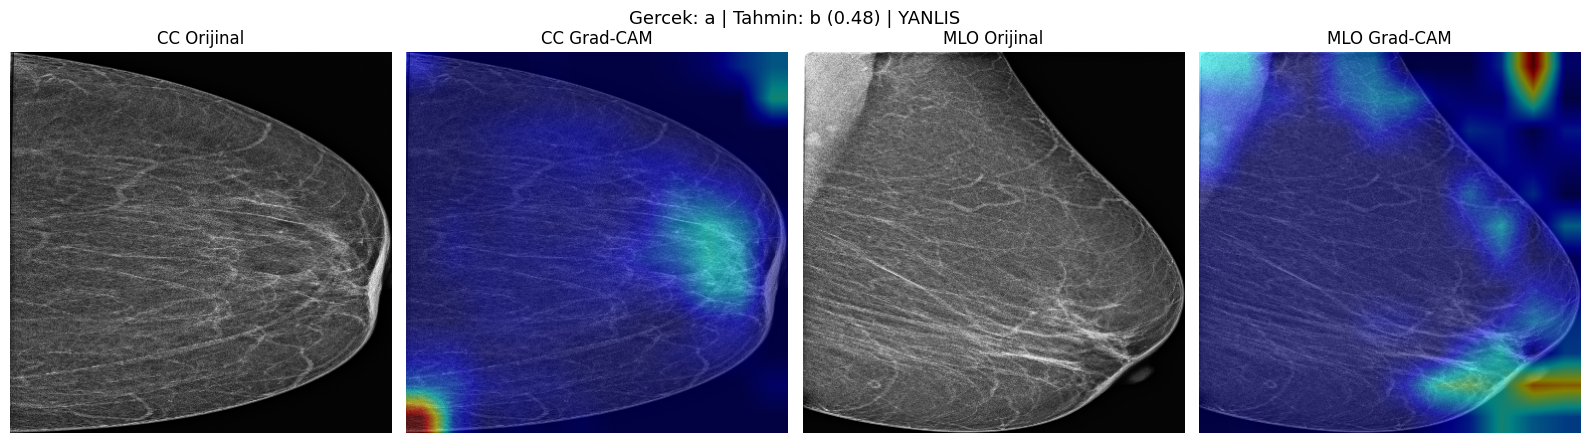

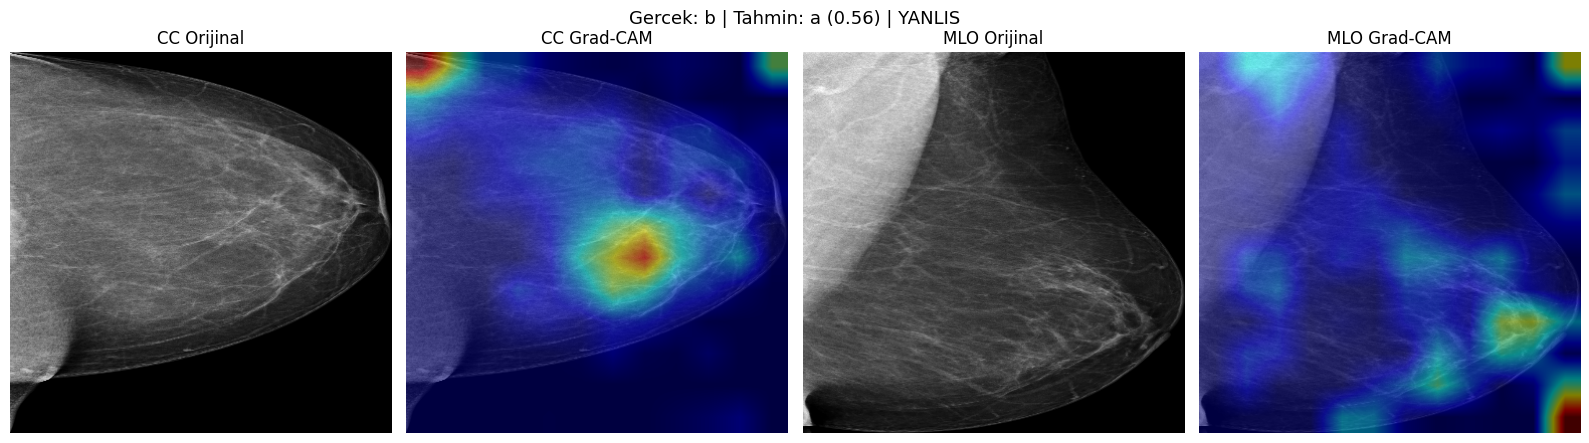

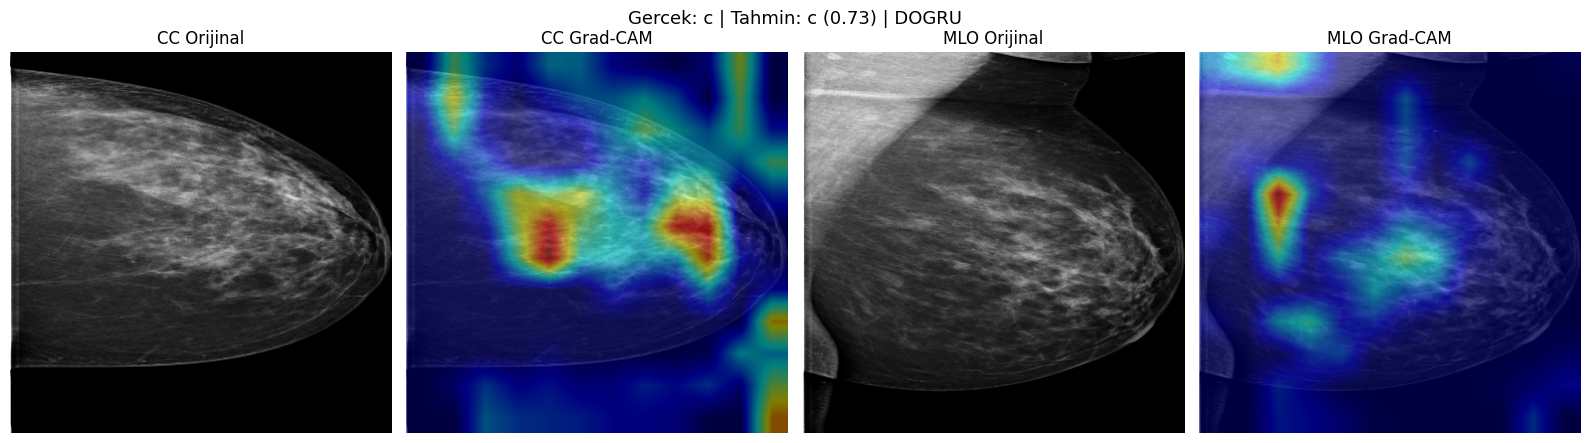

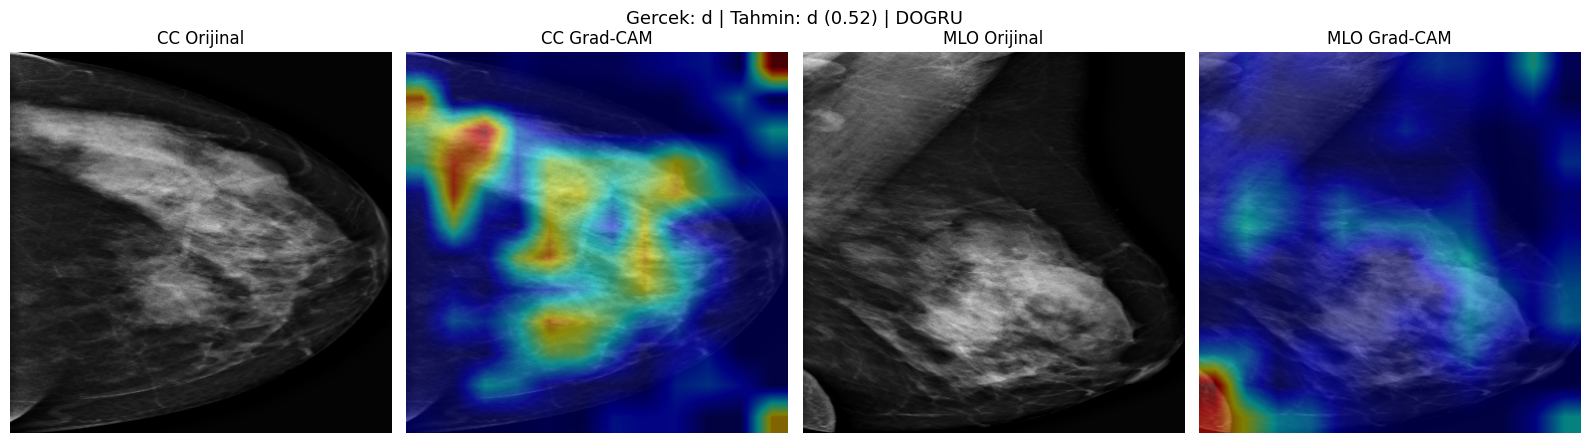

In [ ]:
import torch
import torch.nn.functional as F
from torch.amp import autocast
import numpy as np
import cv2
import matplotlib.pyplot as plt

class GradCAMEffUNet:
    # Grad-CAM for one branch's encoder (last stage)
    # Bir dalin encoder'i icin Grad-CAM (son asama)

    def __init__(self, model, branch):
        self.model = model
        self.model.eval()
        # Target: last encoder stage of the chosen branch
        # Hedef: secilen dalin son encoder asamasi
        b = model.cc_branch if branch == "cc" else model.mlo_branch
        self.target_layer = b.encoder.stage4

        self.activations = None
        self.gradients = None
        self.target_layer.register_forward_hook(self._save_act)
        self.target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, m, i, o):
        self.activations = o.detach()

    def _save_grad(self, m, gi, go):
        self.gradients = go[0].detach()

    def generate(self, cc, mlo, target_class=None):
        # Forward in float32 (AMP off for gradient stability)
        # float32 ileri gecis (gradyan kararliligi icin AMP kapali)
        output = self.model(cc, mlo)
        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, target_class].backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        probs = F.softmax(output, dim=1)[0].detach().cpu().numpy()
        return cam, target_class, probs

def overlay_cam(img_rgb, cam, alpha=0.5):
    cam_r = cv2.resize(cam, (img_rgb.shape[1], img_rgb.shape[0]))
    hm = cv2.applyColorMap(np.uint8(255 * cam_r), cv2.COLORMAP_JET)
    hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB)
    return np.uint8(alpha * hm + (1 - alpha) * img_rgb)

# Reload best model (make sure it's the trained one)
# En iyi modeli tekrar yukle (egitilmis oldugundan emin ol)
ck = torch.load(BEST_CKPT, map_location=device)
model.load_state_dict(ck["model_state"])
model.eval()

gc_cc = GradCAMEffUNet(model, "cc")
gc_mlo = GradCAMEffUNet(model, "mlo")
print("Grad-CAM hazir.")

def visualize(row):
    cc_img = cv2.cvtColor(cv2.imread(row["cc_path"], cv2.IMREAD_GRAYSCALE), cv2.COLOR_GRAY2RGB)
    mlo_img = cv2.cvtColor(cv2.imread(row["mlo_path"], cv2.IMREAD_GRAYSCALE), cv2.COLOR_GRAY2RGB)

    cc_t = eval_transform(image=cc_img)["image"].unsqueeze(0).to(device)
    mlo_t = eval_transform(image=mlo_img)["image"].unsqueeze(0).to(device)

    cam_cc, pred, probs = gc_cc.generate(cc_t, mlo_t)
    cam_mlo, _, _ = gc_mlo.generate(cc_t, mlo_t)

    # Resize originals to model input size for overlay
    # Bindirme icin orijinalleri model giris boyutuna getir
    cc_disp = cv2.resize(cc_img, (IMG_SIZE, IMG_SIZE))
    mlo_disp = cv2.resize(mlo_img, (IMG_SIZE, IMG_SIZE))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
    axes[0].imshow(cc_disp); axes[0].set_title("CC Orijinal"); axes[0].axis("off")
    axes[1].imshow(overlay_cam(cc_disp, cam_cc)); axes[1].set_title("CC Grad-CAM"); axes[1].axis("off")
    axes[2].imshow(mlo_disp); axes[2].set_title("MLO Orijinal"); axes[2].axis("off")
    axes[3].imshow(overlay_cam(mlo_disp, cam_mlo)); axes[3].set_title("MLO Grad-CAM"); axes[3].axis("off")

    status = "DOGRU" if CLASSES[pred] == row["label"] else "YANLIS"
    plt.suptitle(f"Gercek: {row['label']} | Tahmin: {CLASSES[pred]} ({probs[pred]:.2f}) | {status}", fontsize=13)
    plt.tight_layout()
    plt.show()

# One test example per class
# Sinif basina bir test ornegi
test_rows = breast_df[breast_df["split"] == "test"]
for cls in CLASSES:
    rows = test_rows[test_rows["label"] == cls]
    if len(rows) > 0:
        visualize(rows.iloc[0])

kırpılmış görüntüler ile tekrardan eğitim

In [ ]:
import os
import pandas as pd
import torch

# Reload table and set new output folder for the cropped experiment
# Tabloyu tekrar yukle ve kirpilmis deney icin yeni cikti klasoru
DATA_ROOT = "/content/drive/MyDrive/mini_dataset_2000"
OLD_ROOT = "/content/drive/MyDrive/breast_density/EfficientNetUNet_paper_faithful"
OUTPUT_ROOT = "/content/drive/MyDrive/breast_density/EfficientNetUNet_cropped"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

CLASSES = ["a", "b", "c", "d"]
IMG_SIZE = 380
BATCH_SIZE = 8
ACCUM_STEPS = 2
MAX_EPOCHS = 50
PATIENCE = 10
LR_ENCODER = 1e-5
LR_DECODER = 1e-4
LABEL_SMOOTHING = 0.1
DROPOUT = 0.3
T_0 = 5
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the table with splits from the old experiment (same split, comparable)
# Eski deneyden split'li tabloyu yukle (ayni split, karsilastirilabilir)
breast_df = pd.read_csv(os.path.join(OLD_ROOT, "breast_table.csv"))
print("Tablo yuklendi. Split dagilimi:")
print(breast_df["split"].value_counts())

Tablo yuklendi. Split dagilimi:
split
train    3200
test      400
val       400
Name: count, dtype: int64


In [ ]:
# Reuse cropped images already produced for the Nguyen model
# Nguyen modeli icin uretilmis kirpilmis goruntuleri tekrar kullan
NGUYEN_PROC = "/content/drive/MyDrive/breast_density/NguyenLightGBM_paper_faithful/dataset_processed"

def cropped_path(orig_path, label):
    fname = os.path.basename(orig_path)
    return os.path.join(NGUYEN_PROC, label, fname)

breast_df["cc_cropped"] = breast_df.apply(lambda r: cropped_path(r["cc_path"], r["label"]), axis=1)
breast_df["mlo_cropped"] = breast_df.apply(lambda r: cropped_path(r["mlo_path"], r["label"]), axis=1)

missing = (~breast_df["cc_cropped"].apply(os.path.exists)).sum() + \
          (~breast_df["mlo_cropped"].apply(os.path.exists)).sum()
print(f"Eksik kirpilmis goruntu: {missing}")
assert missing == 0, "Kirpilmis goruntuler bulunamadi!"
print("Kirpilmis yollar eklendi.")

Eksik kirpilmis goruntu: 0
Kirpilmis yollar eklendi.


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
import cv2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Affine(translate_percent=0.0625, scale=(0.9, 1.1), rotate=(-15, 15),
             border_mode=cv2.BORDER_CONSTANT, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.CoarseDropout(num_holes_range=(4, 8),
                    hole_height_range=(int(IMG_SIZE*0.05), int(IMG_SIZE*0.1)),
                    hole_width_range=(int(IMG_SIZE*0.05), int(IMG_SIZE*0.1)),
                    fill=0, p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

class CroppedTwoViewDataset(Dataset):
    # Two-view dataset using cropped breast images
    # Kirpilmis meme goruntuleri ile iki gorunumlu veri seti

    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _load(self, path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Okunamadi: {path}")
        return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        cc = self._load(row["cc_cropped"])
        mlo = self._load(row["mlo_cropped"])
        cc = self.transform(image=cc)["image"]
        mlo = self.transform(image=mlo)["image"]
        return cc, mlo, int(row["label_idx"])

train_df = breast_df[breast_df["split"] == "train"].copy()
val_df = breast_df[breast_df["split"] == "val"].copy()
test_df = breast_df[breast_df["split"] == "test"].copy()

train_loader = DataLoader(CroppedTwoViewDataset(train_df, train_transform),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
                          pin_memory=True, drop_last=True)
val_loader = DataLoader(CroppedTwoViewDataset(val_df, eval_transform),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(CroppedTwoViewDataset(test_df, eval_transform),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Kirpilmis DataLoader'lar hazir.")
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
cc, mlo, lbl = next(iter(train_loader))
print(f"CC: {cc.shape}, MLO: {mlo.shape}")

Kirpilmis DataLoader'lar hazir.
Train: 3200, Val: 400, Test: 400
CC: torch.Size([8, 3, 380, 380]), MLO: torch.Size([8, 3, 380, 380])


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as tv_models

class EfficientNetB4Encoder(nn.Module):
    # EfficientNet-B4 encoder from torchvision
    # torchvision'dan EfficientNet-B4 encoder
    def __init__(self, pretrained=True):
        super().__init__()
        weights = tv_models.EfficientNet_B4_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = tv_models.efficientnet_b4(weights=weights)
        feats = backbone.features

        self.stage0 = nn.Sequential(feats[0], feats[1])
        self.stage1 = feats[2]
        self.stage2 = feats[3]
        self.stage3 = nn.Sequential(feats[4], feats[5])
        self.stage4 = nn.Sequential(feats[6], feats[7])
        self.out_channels = [24, 32, 56, 160, 448]

    def forward(self, x):
        f0 = self.stage0(x)
        f1 = self.stage1(f0)
        f2 = self.stage2(f1)
        f3 = self.stage3(f2)
        f4 = self.stage4(f3)
        return [f0, f1, f2, f3, f4]

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class EfficientNetUNetBranch(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.encoder = EfficientNetB4Encoder(pretrained=pretrained)
        ch = self.encoder.out_channels

        self.up4 = nn.ConvTranspose2d(ch[4], ch[3], kernel_size=2, stride=2)
        self.dec4 = ConvBlock(ch[3] * 2, ch[3])
        self.up3 = nn.ConvTranspose2d(ch[3], ch[2], kernel_size=2, stride=2)
        self.dec3 = ConvBlock(ch[2] * 2, ch[2])
        self.up2 = nn.ConvTranspose2d(ch[2], ch[1], kernel_size=2, stride=2)
        self.dec2 = ConvBlock(ch[1] * 2, ch[1])
        self.up1 = nn.ConvTranspose2d(ch[1], ch[0], kernel_size=2, stride=2)
        self.dec1 = ConvBlock(ch[0] * 2, ch[0])

        self.out_channels = ch[0]
        self.gap = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        feats = self.encoder(x)
        d4 = self._match_and_cat(self.up4(feats[4]), feats[3]); d4 = self.dec4(d4)
        d3 = self._match_and_cat(self.up3(d4), feats[2]); d3 = self.dec3(d3)
        d2 = self._match_and_cat(self.up2(d3), feats[1]); d2 = self.dec2(d2)
        d1 = self._match_and_cat(self.up1(d2), feats[0]); d1 = self.dec1(d1)
        return torch.flatten(self.gap(d1), 1)

    @staticmethod
    def _match_and_cat(up, skip):
        if up.shape[-2:] != skip.shape[-2:]:
            up = nn.functional.interpolate(up, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return torch.cat([up, skip], dim=1)

class EfficientNetUNet(nn.Module):
    def __init__(self, num_classes=4, pretrained=True, dropout=0.3):
        super().__init__()
        self.cc_branch = EfficientNetUNetBranch(pretrained=pretrained)
        self.mlo_branch = EfficientNetUNetBranch(pretrained=pretrained)
        feat_dim = self.cc_branch.out_channels
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(feat_dim * 2, num_classes))

    def forward(self, cc, mlo):
        cc_feat = self.cc_branch(cc)
        mlo_feat = self.mlo_branch(mlo)
        fused = torch.cat([cc_feat, mlo_feat], dim=1)
        return self.classifier(fused)

print("Model sinifi tanimlandi (kirpilmis deney icin).")

Model sinifi tanimlandi (kirpilmis deney icin).


In [ ]:
import torch.optim as optim
import os
import shutil

LOCAL_OUT = "/content/local_out_effunet_cropped"
os.makedirs(LOCAL_OUT, exist_ok=True)
SYNC_EVERY = 10   # dersimizden ogrendigimiz deger

LAST_CKPT = os.path.join(LOCAL_OUT, "last.pt")
BEST_CKPT = os.path.join(LOCAL_OUT, "best.pt")
EXCEL_LOG = os.path.join(LOCAL_OUT, "log.xlsx")
DRIVE_CKPT_DIR = os.path.join(OUTPUT_ROOT, "checkpoints")

model = EfficientNetUNet(num_classes=4, pretrained=True, dropout=DROPOUT).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

encoder_params = list(model.cc_branch.encoder.parameters()) + list(model.mlo_branch.encoder.parameters())
encoder_ids = {id(p) for p in encoder_params}
decoder_params = [p for p in model.parameters() if id(p) not in encoder_ids]

optimizer = optim.AdamW([
    {"params": encoder_params, "lr": LR_ENCODER},
    {"params": decoder_params, "lr": LR_DECODER},
])
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=T_0)

def save_ckpt(path, epoch, model, optimizer, scheduler, best_val_loss, no_improve):
    torch.save({
        "epoch": epoch, "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_loss": best_val_loss, "no_improve": no_improve,
    }, path)

def sync_to_drive(local_dir, drive_dir):
    # Copy needed files only, no rmtree (avoids Drive freeze)
    # Sadece gerekli dosyalari kopyala, rmtree yok (Drive donmasini onler)
    os.makedirs(drive_dir, exist_ok=True)
    for fname in ["last.pt", "best.pt", "log.xlsx"]:
        src = os.path.join(local_dir, fname)
        if not os.path.exists(src):
            continue
        try:
            shutil.copy2(src, os.path.join(drive_dir, fname))
        except Exception as e:
            print(f"  Uyari: {fname} Drive'a yazilamadi ({e})")

start_epoch, best_val_loss, no_improve = 0, float("inf"), 0

if not os.path.exists(LAST_CKPT) and os.path.exists(os.path.join(DRIVE_CKPT_DIR, "last.pt")):
    sync_to_drive(DRIVE_CKPT_DIR, LOCAL_OUT)
    print("Drive'dan checkpoint cekildi.")

if os.path.exists(LAST_CKPT):
    ck = torch.load(LAST_CKPT, map_location=device)
    model.load_state_dict(ck["model_state"])
    optimizer.load_state_dict(ck["optimizer_state"])
    scheduler.load_state_dict(ck["scheduler_state"])
    start_epoch = ck["epoch"] + 1
    best_val_loss = ck["best_val_loss"]
    no_improve = ck["no_improve"]
    print(f"Checkpoint bulundu. Epoch {start_epoch}'dan devam ediliyor.")
else:
    print("Sifirdan baslaniyor (kirpilmis goruntulerle).")

from torch.amp import GradScaler
scaler = GradScaler("cuda")
print("Mixed precision (AMP) aktif.")
print(f"Kurulum: AdamW (enc {LR_ENCODER}, dec {LR_DECODER}), CosineWarmRestarts T_0={T_0}")

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 137MB/s]


Drive'dan checkpoint cekildi.
Checkpoint bulundu. Epoch 40'dan devam ediliyor.
Mixed precision (AMP) aktif.
Kurulum: AdamW (enc 1e-05, dec 0.0001), CosineWarmRestarts T_0=5


In [ ]:
import numpy as np
import torch.nn.functional as F
from torch.amp import autocast
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    for cc, mlo, labels in loader:
        cc, mlo, labels = cc.to(device), mlo.to(device), labels.to(device)
        with autocast("cuda"):
            outputs = model(cc, mlo)
            loss = criterion(outputs, labels)
        total_loss += loss.item() * labels.size(0)
        probs = F.softmax(outputs.float(), dim=1)
        all_preds.append(outputs.argmax(dim=1).cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)

    metrics = {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
    }
    try:
        metrics["macro_auc"] = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
    except ValueError:
        metrics["macro_auc"] = float("nan")

    return metrics, all_labels, all_preds, all_probs

print("Metrik fonksiyonu hazir.")

Metrik fonksiyonu hazir.


In [ ]:
from tqdm import tqdm
from torch.amp import autocast
import pandas as pd

if os.path.exists(EXCEL_LOG):
    _df = pd.read_excel(EXCEL_LOG)
    _df = _df[_df["epoch"] < start_epoch]
    log_rows = _df.to_dict("records")
else:
    log_rows = []

def train_one_epoch(model, loader, criterion, optimizer, device, scaler, accum_steps=1):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()
    for i, (cc, mlo, labels) in enumerate(tqdm(loader, desc="Train", leave=False)):
        cc, mlo, labels = cc.to(device), mlo.to(device), labels.to(device)
        with autocast("cuda"):
            outputs = model(cc, mlo)
            loss = criterion(outputs, labels)
        scaler.scale(loss / accum_steps).backward()
        if (i + 1) % accum_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        total_loss += loss.item() * labels.size(0)
    if len(loader) % accum_steps != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
    return total_loss / len(loader.dataset)

print(f"Egitim basliyor (kirpilmis goruntuler). Epoch {start_epoch} -> {MAX_EPOCHS - 1}")
print(f"Efektif batch: {BATCH_SIZE} x {ACCUM_STEPS} = {BATCH_SIZE * ACCUM_STEPS}\n")

for epoch in range(start_epoch, MAX_EPOCHS):
    train_one_epoch(model, train_loader, criterion, optimizer, device, scaler, accum_steps=ACCUM_STEPS)

    tr_m, _, _, _ = evaluate(model, train_loader, criterion, device)
    va_m, _, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step()
    lr_enc = optimizer.param_groups[0]["lr"]
    lr_dec = optimizer.param_groups[1]["lr"]

    print(f"E{epoch:02d} | tr_loss {tr_m['loss']:.3f} acc {tr_m['accuracy']:.3f} | "
          f"va_loss {va_m['loss']:.3f} acc {va_m['accuracy']:.3f} f1 {va_m['macro_f1']:.3f} | "
          f"lr {lr_enc:.1e}/{lr_dec:.1e}")

    row = {"epoch": epoch, "lr_encoder": lr_enc, "lr_decoder": lr_dec}
    for k, v in tr_m.items(): row[f"train_{k}"] = v
    for k, v in va_m.items(): row[f"val_{k}"] = v
    log_rows.append(row)
    pd.DataFrame(log_rows).to_excel(EXCEL_LOG, index=False)

    if va_m["loss"] < best_val_loss:
        best_val_loss = va_m["loss"]
        no_improve = 0
        save_ckpt(BEST_CKPT, epoch, model, optimizer, scheduler, best_val_loss, no_improve)
        print(f"  -> Yeni en iyi val loss: {best_val_loss:.4f}")
    else:
        no_improve += 1
        print(f"  -> Iyilesme yok ({no_improve}/{PATIENCE})")

    save_ckpt(LAST_CKPT, epoch, model, optimizer, scheduler, best_val_loss, no_improve)

    if (epoch + 1) % SYNC_EVERY == 0:
        sync_to_drive(LOCAL_OUT, DRIVE_CKPT_DIR)
        print("  (Drive'a senkronize edildi)")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping: {PATIENCE} epoch iyilesme yok.")
        break

sync_to_drive(LOCAL_OUT, DRIVE_CKPT_DIR)
print(f"\nEgitim tamamlandi. En iyi val loss: {best_val_loss:.4f}")

Egitim basliyor (kirpilmis goruntuler). Epoch 0 -> 49
Efektif batch: 8 x 2 = 16



E00 | tr_loss 1.131 acc 0.525 | va_loss 1.100 acc 0.573 f1 0.335 | lr 9.0e-06/9.0e-05
  -> Yeni en iyi val loss: 1.0996


E01 | tr_loss 0.980 acc 0.665 | va_loss 0.966 acc 0.685 f1 0.550 | lr 6.5e-06/6.5e-05
  -> Yeni en iyi val loss: 0.9660


E02 | tr_loss 0.952 acc 0.677 | va_loss 0.948 acc 0.670 f1 0.533 | lr 3.5e-06/3.5e-05
  -> Yeni en iyi val loss: 0.9485


E03 | tr_loss 0.921 acc 0.694 | va_loss 0.914 acc 0.703 f1 0.566 | lr 9.5e-07/9.5e-06
  -> Yeni en iyi val loss: 0.9144


...

E35 | tr_loss 0.733 acc 0.786 | va_loss 0.820 acc 0.720 f1 0.692 | lr 9.0e-06/9.0e-05
  -> Iyilesme yok (6/10)


E36 | tr_loss 0.707 acc 0.819 | va_loss 0.827 acc 0.748 f1 0.734 | lr 6.5e-06/6.5e-05
  -> Iyilesme yok (7/10)


E37 | tr_loss 0.694 acc 0.832 | va_loss 0.806 acc 0.738 f1 0.714 | lr 3.5e-06/3.5e-05
  -> Iyilesme yok (8/10)


E38 | tr_loss 0.695 acc 0.830 | va_loss 0.801 acc 0.743 f1 0.724 | lr 9.5e-07/9.5e-06
  -> Iyilesme yok (9/10)


E39 | tr_loss 0.700 acc 0.823 | va_loss 0.809 acc 0.735 f1 0.723 | lr 1.0e-05/1.0e-04
  -> Iyilesme yok (10/10)
  (Drive'a senkronize edildi)

Early stopping: 10 epoch iyilesme yok.

Egitim tamamlandi. En iyi val loss: 0.7988


In [ ]:
import torch
import numpy as np
import torch.nn.functional as F
from torch.amp import autocast
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, cohen_kappa_score, roc_auc_score)
import pandas as pd

# Load best model from the cropped experiment
# Kirpilmis deneyden en iyi modeli yukle
ck = torch.load(BEST_CKPT, map_location=device)
model.load_state_dict(ck["model_state"])
model.eval()
print(f"En iyi model yuklendi (epoch {ck['epoch']}, val_loss {ck['best_val_loss']:.4f})")

@torch.no_grad()
def evaluate_full(model, loader, device):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for cc, mlo, labels in loader:
        cc, mlo = cc.to(device), mlo.to(device)
        with autocast("cuda"):
            outputs = model(cc, mlo)
        probs = F.softmax(outputs.float(), dim=1)
        all_preds.append(outputs.argmax(dim=1).cpu().numpy())
        all_labels.append(labels.numpy())
        all_probs.append(probs.cpu().numpy())
    return (np.concatenate(all_labels), np.concatenate(all_preds),
            np.concatenate(all_probs))

y_test, preds_test, probs_test = evaluate_full(model, test_loader, device)

print("EFFICIENTNET-UNET (KIRPILMIS) TEST SONUCLARI")
print(f"Accuracy:        {accuracy_score(y_test, preds_test):.4f}")
print(f"Macro F1:        {f1_score(y_test, preds_test, average='macro'):.4f}")
print(f"Macro AUC:       {roc_auc_score(y_test, probs_test, multi_class='ovr', average='macro'):.4f}")
print(f"Cohen Kappa:     {cohen_kappa_score(y_test, preds_test):.4f}")
print(f"Weighted Kappa:  {cohen_kappa_score(y_test, preds_test, weights='quadratic'):.4f}")

print("\nSiniflandirma Raporu")
print(classification_report(y_test, preds_test, target_names=CLASSES, digits=3))

print("Confusion Matrix")
cm = confusion_matrix(y_test, preds_test)
print(pd.DataFrame(cm, index=[f"gercek_{c}" for c in CLASSES],
                   columns=[f"tahmin_{c}" for c in CLASSES]))

En iyi model yuklendi (epoch 29, val_loss 0.7988)
EFFICIENTNET-UNET (KIRPILMIS) TEST SONUCLARI
Accuracy:        0.7175
Macro F1:        0.7167
Macro AUC:       0.9245
Cohen Kappa:     0.6056
Weighted Kappa:  0.8389

Siniflandirma Raporu
              precision    recall  f1-score   support

           a      0.562     0.783     0.655        46
           b      0.756     0.649     0.698       148
           c      0.712     0.739     0.725       134
           d      0.800     0.778     0.789        72

    accuracy                          0.718       400
   macro avg      0.708     0.737     0.717       400
weighted avg      0.727     0.718     0.719       400

Confusion Matrix
          tahmin_a  tahmin_b  tahmin_c  tahmin_d
gercek_a        36        10         0         0
gercek_b        28        96        24         0
gercek_c         0        21        99        14
gercek_d         0         0        16        56


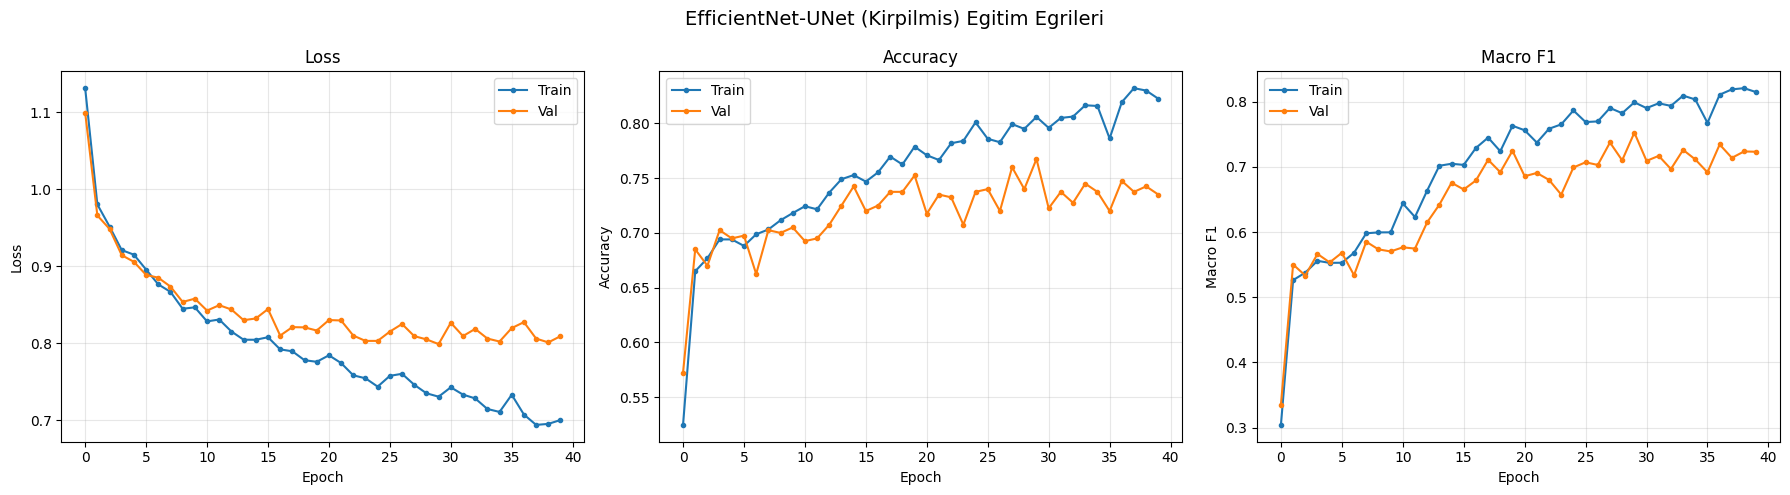

Kaydedildi: /content/drive/MyDrive/breast_density/EfficientNetUNet_cropped/cropped_training_curves.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

log_path = os.path.join(DRIVE_CKPT_DIR, "log.xlsx")
if not os.path.exists(log_path):
    log_path = EXCEL_LOG
log_df = pd.read_excel(log_path)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric, title) in zip(axes, [("loss", "Loss"),
                                       ("accuracy", "Accuracy"),
                                       ("macro_f1", "Macro F1")]):
    ax.plot(log_df["epoch"], log_df[f"train_{metric}"], marker="o", markersize=3, label="Train")
    ax.plot(log_df["epoch"], log_df[f"val_{metric}"], marker="o", markersize=3, label="Val")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("EfficientNet-UNet (Kirpilmis) Egitim Egrileri", fontsize=14)
plt.tight_layout()

save_path = os.path.join(OUTPUT_ROOT, "cropped_training_curves.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaydedildi: {save_path}")

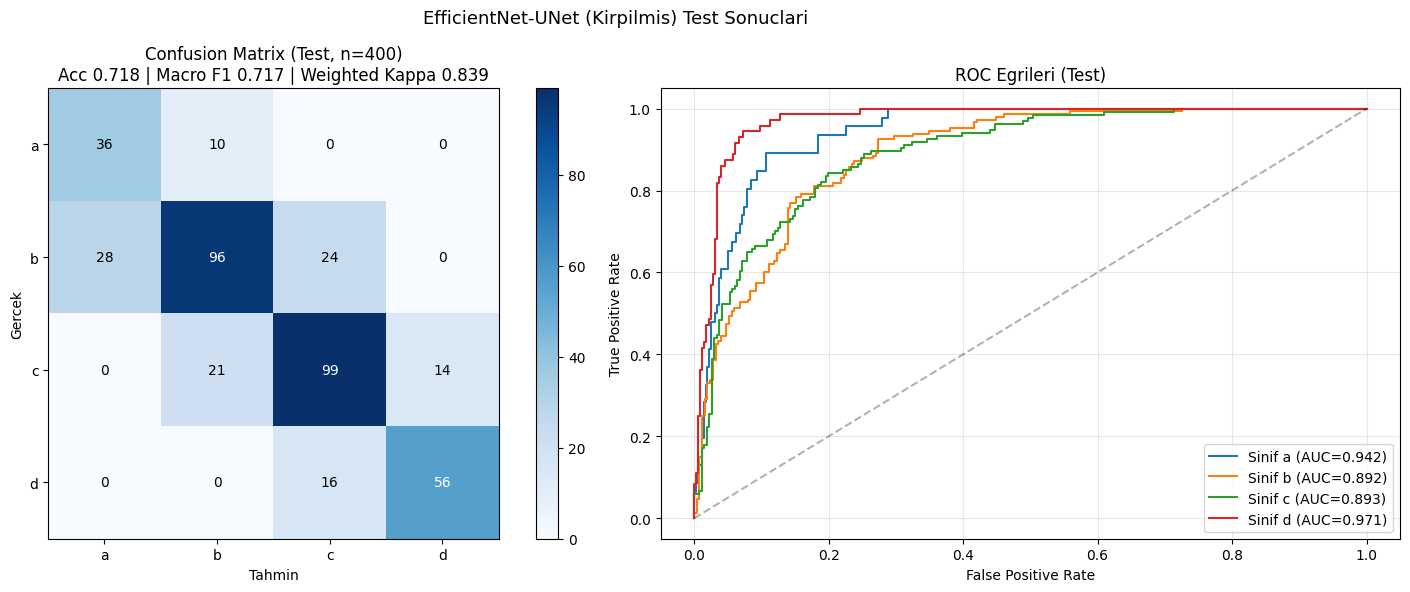

Kaydedildi: /content/drive/MyDrive/breast_density/EfficientNetUNet_cropped/cropped_test_confusion_roc.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                             accuracy_score, f1_score, cohen_kappa_score)
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, preds_test)
im = axes[0].imshow(cm, cmap="Blues")

acc = accuracy_score(y_test, preds_test)
mf1 = f1_score(y_test, preds_test, average="macro")
wk = cohen_kappa_score(y_test, preds_test, weights="quadratic")

axes[0].set_title(f"Confusion Matrix (Test, n={len(y_test)})\n"
                  f"Acc {acc:.3f} | Macro F1 {mf1:.3f} | Weighted Kappa {wk:.3f}")
axes[0].set_xlabel("Tahmin")
axes[0].set_ylabel("Gercek")
axes[0].set_xticks(range(len(CLASSES)))
axes[0].set_yticks(range(len(CLASSES)))
axes[0].set_xticklabels(CLASSES)
axes[0].set_yticklabels(CLASSES)

for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        axes[0].text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=axes[0], fraction=0.046)

y_test_bin = label_binarize(y_test, classes=list(range(len(CLASSES))))
for i, c in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs_test[:, i])
    axes[1].plot(fpr, tpr, label=f"Sinif {c} (AUC={auc(fpr, tpr):.3f})")

axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_title("ROC Egrileri (Test)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("EfficientNet-UNet (Kirpilmis) Test Sonuclari", fontsize=13)
plt.tight_layout()

save_path = os.path.join(OUTPUT_ROOT, "cropped_test_confusion_roc.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaydedildi: {save_path}")

Grad-CAM hazir (kirpilmis model).


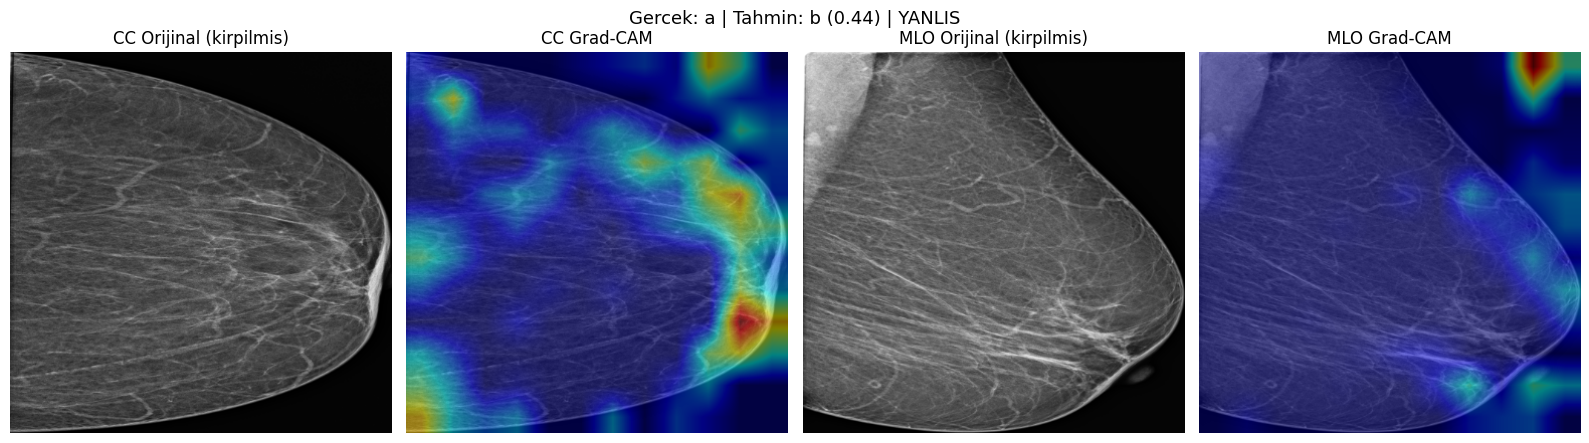

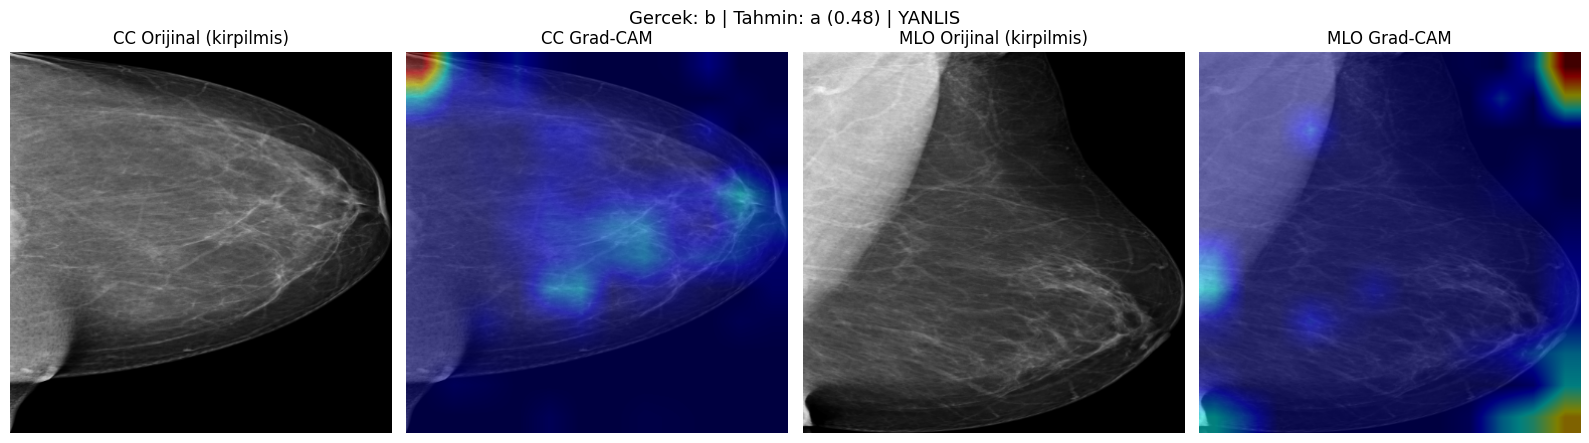

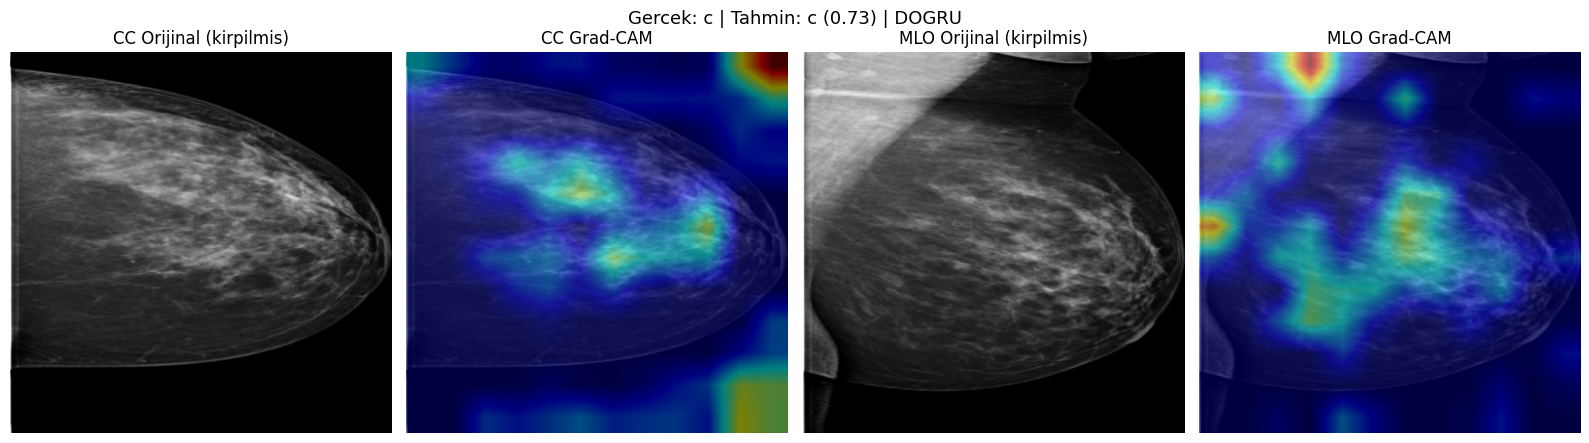

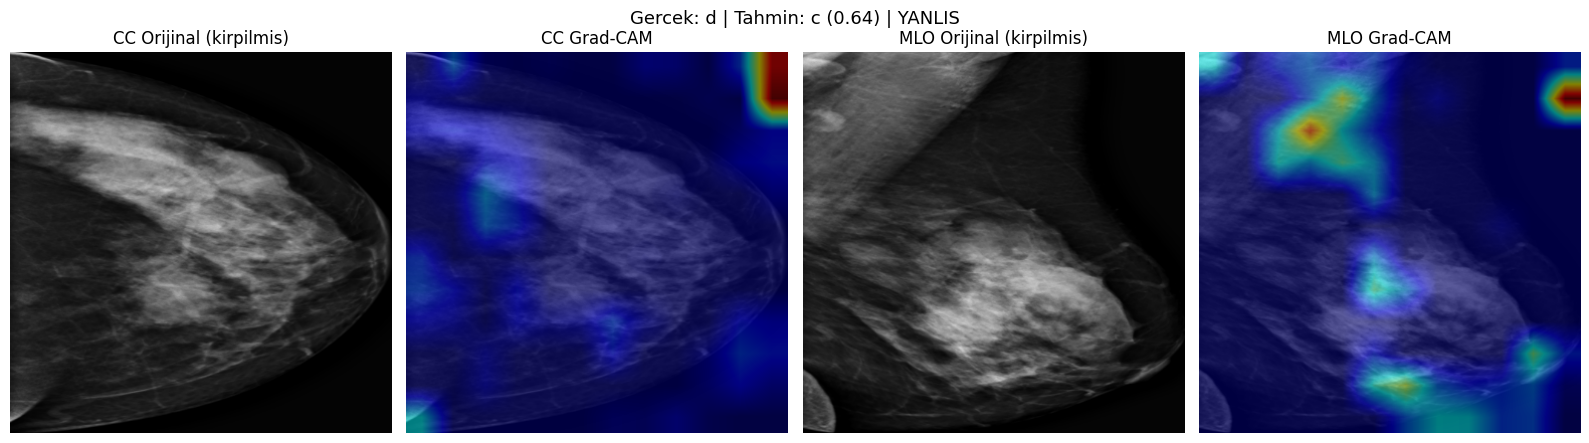

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt

class GradCAMEffUNet:
    def __init__(self, model, branch):
        self.model = model
        self.model.eval()
        b = model.cc_branch if branch == "cc" else model.mlo_branch
        self.target_layer = b.encoder.stage4
        self.activations = None
        self.gradients = None
        self.target_layer.register_forward_hook(self._save_act)
        self.target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, m, i, o):
        self.activations = o.detach()

    def _save_grad(self, m, gi, go):
        self.gradients = go[0].detach()

    def generate(self, cc, mlo, target_class=None):
        output = self.model(cc, mlo)
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, target_class].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        probs = F.softmax(output, dim=1)[0].detach().cpu().numpy()
        return cam, target_class, probs

def overlay_cam(img_rgb, cam, alpha=0.5):
    cam_r = cv2.resize(cam, (img_rgb.shape[1], img_rgb.shape[0]))
    hm = cv2.applyColorMap(np.uint8(255 * cam_r), cv2.COLORMAP_JET)
    hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB)
    return np.uint8(alpha * hm + (1 - alpha) * img_rgb)

ck = torch.load(BEST_CKPT, map_location=device)
model.load_state_dict(ck["model_state"])
model.eval()

gc_cc = GradCAMEffUNet(model, "cc")
gc_mlo = GradCAMEffUNet(model, "mlo")
print("Grad-CAM hazir (kirpilmis model).")

def visualize(row):
    # Use cropped images (this model was trained on them)
    # Kirpilmis goruntuleri kullan (bu model onlarla egitildi)
    cc_img = cv2.cvtColor(cv2.imread(row["cc_cropped"], cv2.IMREAD_GRAYSCALE), cv2.COLOR_GRAY2RGB)
    mlo_img = cv2.cvtColor(cv2.imread(row["mlo_cropped"], cv2.IMREAD_GRAYSCALE), cv2.COLOR_GRAY2RGB)

    cc_t = eval_transform(image=cc_img)["image"].unsqueeze(0).to(device)
    mlo_t = eval_transform(image=mlo_img)["image"].unsqueeze(0).to(device)

    cam_cc, pred, probs = gc_cc.generate(cc_t, mlo_t)
    cam_mlo, _, _ = gc_mlo.generate(cc_t, mlo_t)

    cc_disp = cv2.resize(cc_img, (IMG_SIZE, IMG_SIZE))
    mlo_disp = cv2.resize(mlo_img, (IMG_SIZE, IMG_SIZE))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
    axes[0].imshow(cc_disp); axes[0].set_title("CC Orijinal (kirpilmis)"); axes[0].axis("off")
    axes[1].imshow(overlay_cam(cc_disp, cam_cc)); axes[1].set_title("CC Grad-CAM"); axes[1].axis("off")
    axes[2].imshow(mlo_disp); axes[2].set_title("MLO Orijinal (kirpilmis)"); axes[2].axis("off")
    axes[3].imshow(overlay_cam(mlo_disp, cam_mlo)); axes[3].set_title("MLO Grad-CAM"); axes[3].axis("off")

    status = "DOGRU" if CLASSES[pred] == row["label"] else "YANLIS"
    plt.suptitle(f"Gercek: {row['label']} | Tahmin: {CLASSES[pred]} ({probs[pred]:.2f}) | {status}", fontsize=13)
    plt.tight_layout()
    plt.show()

test_rows = breast_df[breast_df["split"] == "test"]
for cls in CLASSES:
    rows = test_rows[test_rows["label"] == cls]
    if len(rows) > 0:
        visualize(rows.iloc[0])